In [59]:
# IFEOMA MARY-ANN JAMES
# ID : SCA/APC3/DS/171

In [1]:
# loading neccessary libraries
import pandas as pd
import numpy as np
from plotnine import *

In [2]:
telco = pd.read_csv("telco_customer_churn2.csv")
telco

,customer_id,gender,senior_citizen,partner,DEPENDENTS,tenure,pho_ne_service,multi$ple_l@ines,int#e&rnet_service,onli!ne_secur^ity,...,device_protectio+n,TECH_SUP(PORT,st-rea(min(g_tv,streaming_movies,c!ontract,paperless_b%illing,paym#ent_*metho_d,mon^thly_char^ges,t-otal_c(harges,ch_u+rn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7743,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7744,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7745,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7746,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [6]:
telco.info()
print(telco.duplicated().sum())
# it has 705 duplicate rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7748 entries, 0 to 7747
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         7748 non-null   object 
 1   gender              7748 non-null   object 
 2   senior_citizen      7748 non-null   int64  
 3   partner             7748 non-null   object 
 4   DEPENDENTS          7748 non-null   object 
 5   tenure              7748 non-null   int64  
 6   pho_ne_service      7748 non-null   object 
 7   multi$ple_l@ines    7748 non-null   object 
 8   int#e&rnet_service  7748 non-null   object 
 9   onli!ne_secur^ity   7748 non-null   object 
 10  &onl!ine_ba^c@kup   7748 non-null   object 
 11  device_protectio+n  7748 non-null   object 
 12  TECH_SUP(PORT       7748 non-null   object 
 13  st-rea(min(g_tv     7748 non-null   object 
 14  streaming_movies    7748 non-null   object 
 15  c!ontract           7748 non-null   object 
 16  paperl

In [35]:
# i noticed the column  headers have a lot of errors too

telco2 = telco.rename(columns={
    'pho_ne_service'      : 'phone_service',
    'multi$ple_l@ines'    : 'multiple_lines',
    'int#e&rnet_service'  : 'internet_service',
    'onli!ne_secur^ity'   : 'online_security',
    '&onl!ine_ba^c@kup'  : 'online_backup',
    'device_protectio+n'  : 'device_protection',
    'TECH_SUP(PORT'       : 'tech_support',
    'st-rea(min(g_tv'     : 'streaming_tv',
    'c!ontract'           : 'contract',
    'paperless_b%illing'  : 'paperless_billing',
    'paym#ent_*metho_d'   : 'payment_method',
    'mon^thly_char^ges'   : 'monthly_charges',
    't-otal_c(harges'     : 'total_charges',
    'ch_u+rn'            : 'churn',
    'DEPENDENTS'          : 'dependents'
})

telco2
# i forgot to drop the duplicate rows, so i will drop it now
telco2 = telco2.drop_duplicates().reset_index(drop=True)
print(telco2.shape)

(7043, 21)


In [8]:
# next i want to understand my data structure
telco2.ndim          # number of dimensions (2 for dataframe)
telco2.shape         # (rows, columns) — (7748, 21)
telco2.size          # total cells = rows × columns
telco2.columns       # list all column names
telco2.index         # row index info
telco2.dtypes        # data type of each column

customer_id           object
gender                object
senior_citizen         int64
partner               object
DEPENDENTS            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
t-otal_c(harges      float64
ch_u+rn               object
dtype: object

In [9]:
# i noticed three column headers are still incorrect
# lets change them

telco2.columns = telco2.columns.str.replace("ch_u+rn", "churn")

telco2.columns = telco2.columns.str.replace("t-otal_c(harges", "total_charges")

telco2.columns = telco2.columns.str.replace("DEPENDENTS", "dependents")

# i did this below because i noticed the column headers still have space
telco2.columns = telco2.columns.str.replace("churn ", "churn")
telco2.columns = telco2.columns.str.replace("total_charges ", "total_charges")
telco2.columns = telco2.columns.str.replace("dependents ", "dependents")
telco2.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [10]:
telco2.info
telco2.dtypes # i want to check the data structure and to know if the data types are okay

customer_id           object
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
churn                 object
dtype: object

In [11]:
telco2.tail()
# i want to understand my data better

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


In [12]:
telco2["churn"].value_counts()
telco2.columns
# i wanted to know the number of people that churn firstly

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [13]:
# now for us to understand why customers churn, i will be looking at 6 factors
# these are pricing factors, contract type, payment method,utility or value added services and demographics of customers
# sometimes tenure too (because long tenure spreads cost over time)

# for pricing, i have to look at monthly_charges, total_charges
telco2.groupby("churn")[["monthly_charges", "total_charges"]].mean()
# we can see that the monthly_charges are higher for those that left while their total charges is lesser.
# probably a pricing issue

,monthly_charges,total_charges
churn,,
No,61.265124,2555.344141
Yes,74.441332,1531.796094


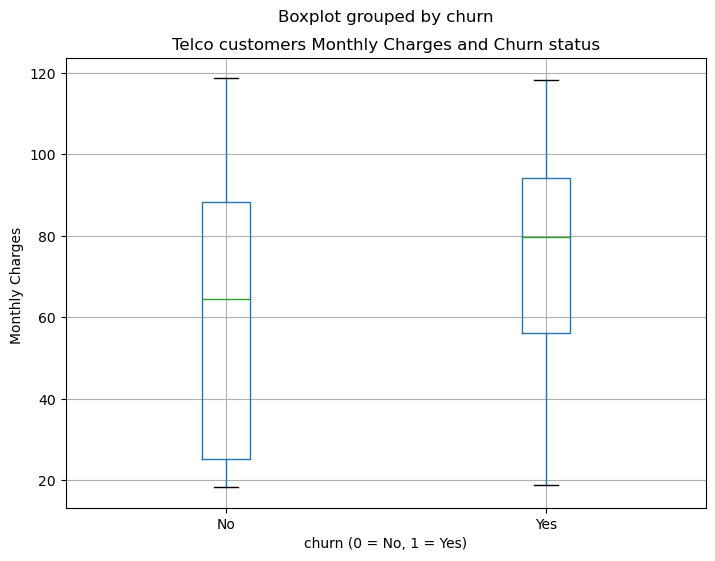

In [14]:
import matplotlib.pyplot as plt
# i want to do a box plot of monthly charges for customers and their churn status
telco2.boxplot( column ="monthly_charges",by = "churn", figsize = (8,6))
plt.title("Telco customers Monthly Charges and Churn status")
plt.xlabel("churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges ")
plt.show()

In [ ]:
# based on the boxplot above, we can see the median monthly charges for those that churned are higher

In [15]:
telco2.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# i noticed that customers that leave have very high monthly charges but less total charges
# therefore i want to understand their contract type
# i want to know if customers that churn are  on a monthly contract or yearly contract

In [16]:
telco2["contract"].value_counts()
# i want to check the contract type so we can group by churn status
# but also i observed that customers on month to month contracts are higher
# does this explain for the high monthly charges?




contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [19]:
churn_by_contract = telco2.groupby("contract")["churn"].value_counts().reset_index()
churn_by_contract
# from all the customers, we can see that month-to-month customers churn the highest followed by 1 year
# while 2 year customers churn the least

# Filter for Yes only
churn_yes = churn_by_contract[churn_by_contract["churn"] == "Yes"]
print(churn_yes)

         contract churn  count
1  Month-to-month   Yes   1655
3        One year   Yes    166
5        Two year   Yes     48


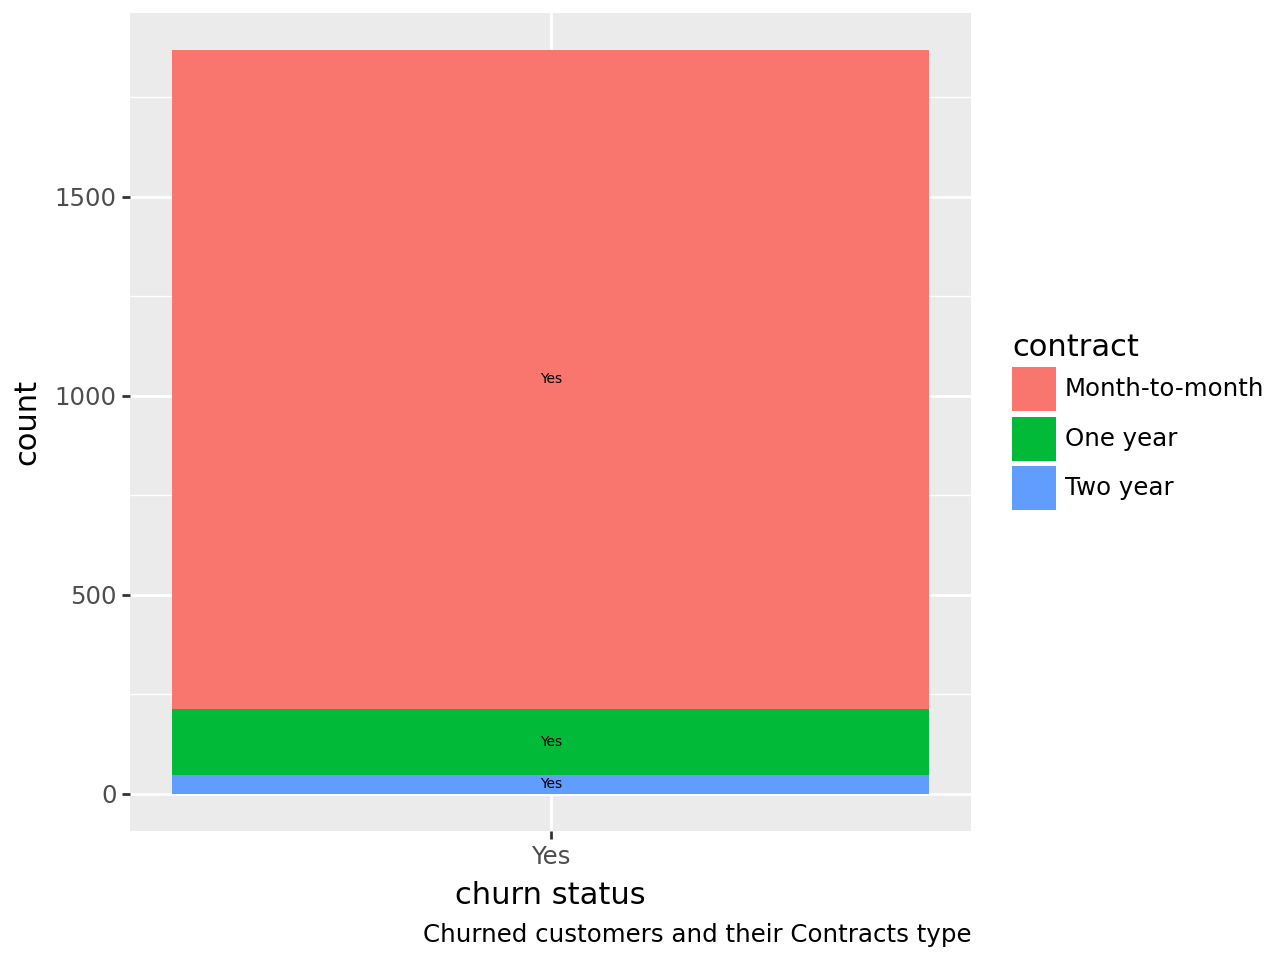

In [36]:
# chart showing the month to month customers churned out the most
(ggplot(churn_yes, aes("churn", "count", fill = "contract")) + geom_col() 
+ geom_text(aes(label = "churn"), position = position_stack(vjust = 0.5), size = 5)
+ labs(x = "churn status",
       y = "count",
       caption = "Churned customers and their Contracts type")
      )

In [21]:
# All value added service columns
# since month to month customers churned out the most, i want to check if there are value added services
# Filter for churned customers only
# Filter month to month AND churned
monthtm_churned = telco2[
    (telco2['contract'] == 'Month-to-month') &
    (telco2['churn'] == 'Yes')
]

print(monthtm_churned)
print(f"Total month-to-month churned customers: {len(monthtm_churned)}")

value_services = ['online_security', 'device_protection', 
                  'tech_support', 'streaming_tv', 
                  'streaming_movies', 'online_backup',
                  'internet_service', 'multiple_lines']

for var in value_services:
    monthtm_churned[var].value_counts(normalize=True).mul(100).round(1)
    # Average monthly charges by each service
for var in value_services:
    print(monthtm_churned.groupby(var)['monthly_charges']
                     .mean()
                     .round(2))

     customer_id  gender  senior_citizen partner dependents  tenure  \
2     3668-QPYBK    Male               0      No         No       2   
4     9237-HQITU  Female               0      No         No       2   
5     9305-CDSKC  Female               0      No         No       8   
8     7892-POOKP  Female               0     Yes         No      28   
13    0280-XJGEX    Male               0      No         No      49   
...          ...     ...             ...     ...        ...     ...   
7018  1122-JWTJW    Male               0     Yes        Yes       1   
7026  8775-CEBBJ  Female               0      No         No       9   
7032  6894-LFHLY    Male               1      No         No       1   
7034  0639-TSIQW  Female               0      No         No      67   
7041  8361-LTMKD    Male               1     Yes         No       4   

     phone_service multiple_lines internet_service online_security  ...  \
2              Yes             No              DSL             Yes  ... 

In [22]:
# Another area i believe that could affect churn is the payment method
# Electronic check -Easiest to cancel ( no commitment)
# Mailed check - Manual effort (may signal disengaged customers)
# Bank transfer (automatic)Automatic — harder to cancel(lower churn)
# Credit card (automatic)Same — automatic payments = more loyal
# Check unique payment methods
telco2['payment_method'].unique()

# Churn rate by payment method
payment_churn = telco2.groupby('payment_method')['churn'].value_counts().reset_index(name = "count").sort_values("count",ascending = False)
# electronic check customers churned out more
# followed by Mailed check( due to the time and stress, customers would not like this
payment_churn.tail()
# we can see that automatic credit card has the least churn

,payment_method,churn,count
0,Bank transfer (automatic),No,1286
5,Electronic check,Yes,1071
7,Mailed check,Yes,308
1,Bank transfer (automatic),Yes,258
3,Credit card (automatic),Yes,232


In [23]:
# for the utility or value-added services, let us check if they have online security or no internet service
#this could be a major concern for churn
print(telco2['online_security'].value_counts())
# a lot of customers with no online security
security_churn =telco2.groupby('online_security')['churn'].value_counts().reset_index(name = "count").sort_values("count",ascending = False)

churn_yes_security = security_churn[security_churn["churn"] == "Yes"]
churn_yes_security

online_security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


,online_security,churn,count
1,No,Yes,1461
5,Yes,Yes,295
3,No internet service,Yes,113


In [24]:
# lastly i need to check the demographic of people that churned out the most
# Check all demographic columns
print(telco2['gender'].unique())
print(telco2['senior_citizen'].unique())
print(telco2['partner'].unique())
print(telco2['dependents'].unique())

['Female' 'Male']
[0 1]
['Yes' 'No']
['No' 'Yes']


In [26]:
senior_churn = (telco2.groupby('senior_citizen')['churn']
                      .value_counts()
                      .reset_index(name='count'))
# senior citizens and their churn status

churn_yes_senior = senior_churn[senior_churn["churn"] == "Yes"]
churn_yes_senior
# senior citizens churned out less

,senior_citizen,churn,count
1,0,Yes,1393
3,1,Yes,476


In [28]:
dependents_churn = (telco2.groupby('dependents')['churn']
                      .value_counts()
                      .reset_index(name='count'))
# senior citizens and their churn status

churn_yes_dependents = dependents_churn[dependents_churn["churn"] == "Yes"]
churn_yes_dependents
# people without dependents churned out more

,dependents,churn,count
1,No,Yes,1543
3,Yes,Yes,326


In [30]:
partner_churn = (telco2.groupby('partner')['churn']
                      .value_counts()
                      .reset_index(name='count'))
# partners  and their churn status

churn_yes_partner = partner_churn[partner_churn["churn"] == "Yes"]
churn_yes_partner
# customers without partners churned out more

,partner,churn,count
1,No,Yes,1200
3,Yes,Yes,669


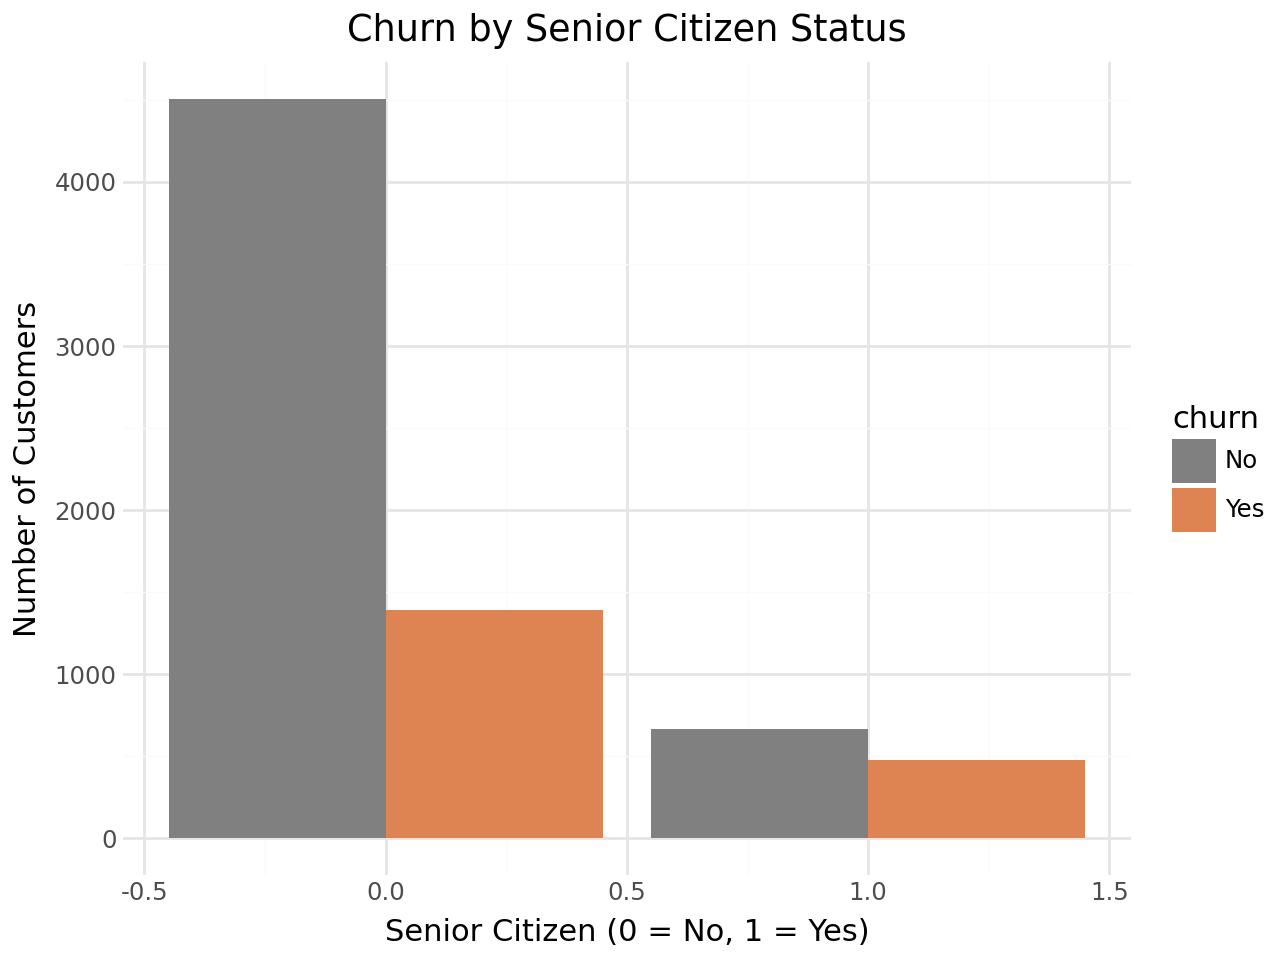

In [31]:
(ggplot(senior_churn, aes(x='senior_citizen',
                           y='count',
                           fill='churn'))
 + geom_col(position='dodge')
 + scale_fill_manual(values={'No': '#808080',
                               'Yes': '#DD8452'})
 + labs(title='Churn by Senior Citizen Status',
        x='Senior Citizen (0 = No, 1 = Yes)',
        y='Number of Customers')
 + theme_minimal()
)

In [66]:
# customers with no dependent, no partner and that are not senior citizens churned out the most

In [32]:
from plotnine import *

# Step 1 — Create tenure groups
# Check the issue
print(telco2['tenure'].min())  # might be 0
print(telco2['tenure'].max())  # might be 72

# Fix — include 0 properly
telco2['tenure_group'] = pd.cut(telco2['tenure'],
                                 bins=[-1, 12, 24, 48, 72],
                                 labels=['0-12 months',
                                         '13-24 months',
                                         '25-48 months',
                                         '49-72 months'])
# this is because i am assuming the tenure is in months even though it wasn't explicitly stated
# also i noticed some values in the tenure column are missing, so that is why in the bins, it started from -1
# this means those customers have not spent up to a month


0
72


C:\Users\USER\anaconda3\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_boxplot : Removed 11 rows containing non-finite values.


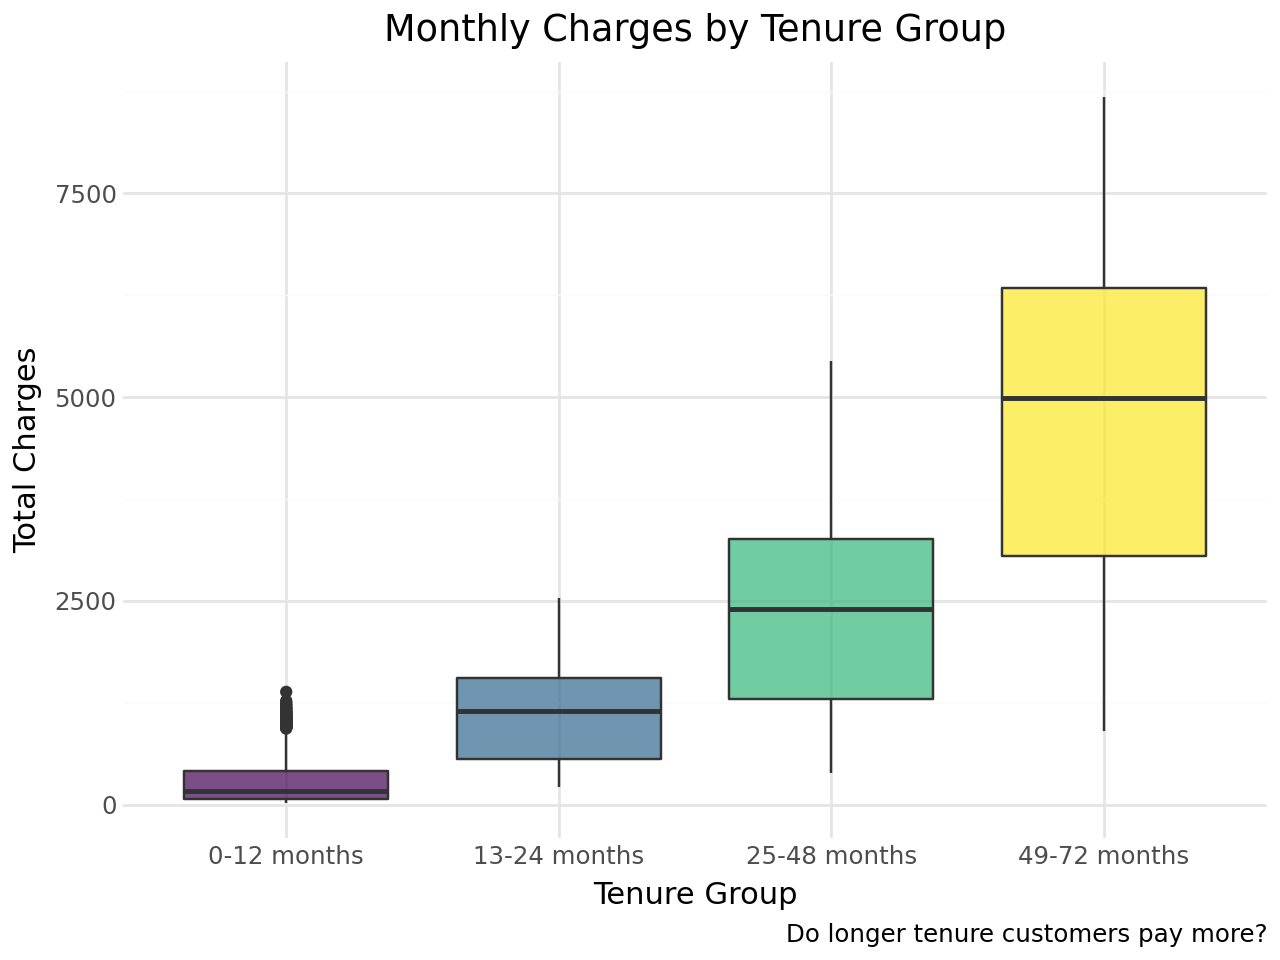

In [33]:
# now let us create a box plot with the tenure groups i created earlier
(ggplot(telco2, aes(x='tenure_group',
                     y='total_charges',
                     fill='tenure_group'))
 + geom_boxplot(alpha=0.7)
 + labs(title='Monthly Charges by Tenure Group',
        x='Tenure Group',
        y='Total Charges',
        caption='Do longer tenure customers pay more?')
 + theme_minimal()
 + theme(legend_position='none')
)
#from the chart we can observe that the median monthly charges is higher than the previous tenure group
# but one thing i noticed is that the 13 to 24 months box is very wide this means that these customers vary in how much they pay.

In [34]:
# since the 49 to 72 tenure box is very wide due to varying total charges, i decided to check the number of people that churned out
# Filter 49-72 months group
tenure_49_72 = telco2[telco2['tenure_group'] == '49-72 months']

# Count churn in this group
print(tenure_49_72['churn'].value_counts())

print("\nChurn rate in 49-72 months group:")
print(tenure_49_72['churn'].value_counts(normalize=True)
                           .mul(100)
                           .round(1))
# i noticed that only 9.5% (213 customers ) churned in this particular group and they have very high total charges
# i think despite the low number,they affect telco company massively in terms of revenue.

churn
No     2026
Yes     213
Name: count, dtype: int64

Churn rate in 49-72 months group:
churn
No     90.5
Yes     9.5
Name: proportion, dtype: float64


## FINDINGS
1. Pricing factors : High monthly charges drive higher churn. 49-72 month customers pay most and this greatly affects revenue because when we looked at the monthly charges box plot with churn, i saw that the median monthly charges was higher for those that churned compared to those that did not.
2. contract type : Month-to-month customers has the highest churn.Month-to-month has approximately 1,500+ churned customers and dominates the entire chart while One year is approximately 150-200 churned customers ( very small slice) and Two year is approximately 50 or fewer churned customers.
3. Payment method : Electronic check has the highest churn.While Automatic payments has the lowest churn.The Friction in payment is that its easier to cancel.
4. Value added services : No online security makes churn higher. Customers without protective services feel less invested in staying.
5. demographics: Customers  without partners or dependents churn most. Senior citizens churn least . stability drives loyalty
6. Tenure : 0-12 month customers churn most. 49-72 months only 9.5% churn. Long tenure customers are the most valuable because of revenue . The box plot of total charges by tenure group clearly shows that median total charges increase from approximately 300 for 0-12 month customers to 5000 for 49-72 month customers  confirming that longer tenure customers generate significantly more revenue.(wider box for 49-72)
   

## REFLECTION
1. The highest risk churn customer is a young single person, on a month-to-month contract, 
paying via electronic check, with no online security.
2. In their first 12 months they face high monthly charges with little value added services . 
3. The lowest risk customer to churn is a family-oriented person on a two year contract paying automatically with value added services, who has been a customer for over 4 years.(49-72) months.
4. Nearly 9 in every 10 customers who left were on month-to-month contracts. this shows that Month-to-month contracts are a retention crisis. The fastest way to reduce overall churn is to reduce the proportion of customers on month-to-month contracts. 
5. Finally to reduce the churn rate, monthly charges should be affordable and also value added services needs to be worked on because customers cannot be paying high online charges with no online security or protective services. Maybe incentives can given to customers to upgrade from Month to month to yearly contracts.
   